<table border=1 width='99%'>
<tr>
<td bgcolor='#d65d0e'>

# **<font color="#ebdbb2"> PC3 - CD1 - Desarrollo de un Modelo de Clasificación de Imágenes </font>**
</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#d79921'>

## **<font color="#fbf1c7"> Introducción</font>**
</td>
</tr>
</table>

El proceso llevado a cabo comprende varias etapas fundamentales:

1. **Descarga de imágenes desde Google**, utilizando herramientas automatizadas para ampliar el dataset original.  
2. **Organización de las imágenes por clases**, siguiendo una estructura clara en carpetas que permita su uso en el entrenamiento del modelo.  
3. **Limpieza, selección y etiquetado de las imágenes**, asegurando que cada clase tenga imágenes válidas, relevantes y de buena calidad.  
4. **Entrenamiento del modelo CNN** utilizando TensorFlow/Keras.  
5. **Optimización de los hiperparámetros** con el fin de mejorar la precisión del modelo.  
6. **Implementación de una interfaz sencilla**, donde el usuario puede subir una imagen y el modelo devuelve la predicción correspondiente.


<table width='99%'>
<tr>
<td bgcolor='#d79921'>

## **<font color="#fbf1c7"> 1. Descarga de Imágenes desde Google: </font>**
</td>
</tr>
</table>

Se realizó una descarga de imágenes utilizando la librería **google_images_download**.

Clases trabajadas


Las clases seleccionadas para el dataset son:

- **daisy**  
- **dandelion**  
- **rose**  
- **sunflower**  
- **tulip**

Cada clase tiene su propia subcarpeta

In [ ]:
!pip install google_images_download

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 19.4 MB/s eta 0:00:00
  Created wheel for google_images_download: filename=google_images_download-2.8.0-py2.py3-none-any.whl size=14538 sha256=4b6387c59765e0fdda5a2aa8e3913dc7c06db1b59640a3d1c4cb07b5b2b81387
  Stored in directory: /root/.cache/pip/wheels/38/be/d2/8124f7a1a8b5bac4a4674ee1b77952778921e63372610b3c60
Successfully built google_images_download


In [1]:
import tensorflow as tf
from tensorflow import keras
import PIL
import cv2

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
from google_images_download import google_images_download
from PIL import Image

# Carpeta train (CAMBIA ESTA RUTA)
train_path = r"C:/Users/Lenovo/Downloads/pc3CD1/archive (14)/train"
clases = ["daisy", "dandelion", "rose", "sunflower", "tulip"]
imagenes_por_clase = 50   # <-- cantidad que quieres agregar por clase
response = google_images_download.googleimagesdownload()
for clase in clases:
    argumentos = {
        "keywords": clase + " flower",
        "limit": imagenes_por_clase,
        "output_directory": train_path,
        "image_directory": clase,
        "print_urls": False,
        "safe_search": True,
        "format": "jpg"
    }
    print(f"Descargando imágenes para: {clase} ...")
    response.download(argumentos)
print("✔ Descarga completada.")

Descargando imágenes para: daisy ...

Item no.: 1 --> Item name = daisy flower
Evaluating...
Starting Download...


Unfortunately all 50 could not be downloaded because some images were not downloadable. 0 is all we got for this search filter!

Errors: 0

Descargando imágenes para: dandelion ...

Item no.: 1 --> Item name = dandelion flower
Evaluating...
Starting Download...


Unfortunately all 50 could not be downloaded because some images were not downloadable. 0 is all we got for this search filter!

Errors: 0

Descargando imágenes para: rose ...

Item no.: 1 --> Item name = rose flower
Evaluating...
Starting Download...


Unfortunately all 50 could not be downloaded because some images were not downloadable. 0 is all we got for this search filter!

Errors: 0

Descargando imágenes para: sunflower ...

Item no.: 1 --> Item name = sunflower flower
Evaluating...
Starting Download...


Unfortunately all 50 could not be downloaded because some images were not downloadable. 0 is all we go

Se descargaron un total **2.695 archivos imágenes nuevas**

| Clase       | Imágenes nuevas |
|-------------|-----------------|
| Daisy       | 501             |
| Dandelion   |  646            |
| Rose        | 468            |
| Sunflower   | 473              |
| Tulip       | 607          |

### Organizar en carpetas por clases

In [ ]:
train_path = r"C:/Users/Lenovo/Downloads/pc3CD1/train"
clases = ["daisy", "dandelion", "rose", "sunflower", "tulip"]
for c in clases:
    ruta = os.path.join(train_path, c)
    total = len(os.listdir(ruta))
    print(f"{c}: {total} imágenes")

### Etiquetar y limpiar imágenes

In [ ]:
def es_valida(path):
    try:
        img = Image.open(path)
        img.verify()
        img = Image.open(path)
        return img.size[0] > 100 and img.size[1] > 100
    except:
        return False
train_path = r"C:/Users/Lenovo/Downloads/pc3CD1/train"
clases = ["daisy", "dandelion", "rose", "sunflower", "tulip"]
for c in clases:
    carpeta = os.path.join(train_path, c)
    archivos = os.listdir(carpeta)
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        if not es_valida(ruta):
            os.remove(ruta)
            print(f"Eliminada: {ruta}")


Después de la descarga masiva de imágenes (2,695 nuevas imágenes), se realizó un proceso de limpieza para asegurar la calidad del dataset.  
Las acciones realizadas fueron:

- Eliminación de imágenes dañadas o corruptas.
- Eliminación de imágenes muy pequeñas (<100 px).
- Eliminación de imágenes duplicadas.
- Eliminación manual de imágenes que no correspondían a la clase (objetos, personas, autos, etc.).
- Verificación final de la estructura de carpetas.

Finalmente, el dataset quedó listo para la etapa de entrenamiento del modelo CNN.

# DESCOMPRIMIR IMAGENES

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving pc3CD1.rar to pc3CD1.rar


In [ ]:
!ls


drive  PC3  pc3CD1  pc3CD1.rar	sample_data


In [ ]:
!apt-get install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [ ]:
!unrar x pc3CD1.rar PC3/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from pc3CD1.rar

Creating    PC3/pc3CD1                                                OK
Creating    PC3/pc3CD1/.ipynb_checkpoints                             OK
Extracting  PC3/pc3CD1/.ipynb_checkpoints/PC3 - CIENCIA DE DATOS-checkpoint.ipynb       0%  OK 
Extracting  PC3/pc3CD1/PC3 - CIENCIA DE DATOS.ipynb                        0%  OK 
Creating    PC3/pc3CD1/test                                           OK
Extracting  PC3/pc3CD1/test/Image_1.jpg                                    0%  OK 
Extracting  PC3/pc3CD1/test/Image_10.jpg                                   0%  OK 
Extracting  PC3/pc3CD1/test/Image_100.jpg                                  0%  OK 
Extracting  PC3/pc3CD1/test/Image_101.jpg                                  0%  OK 
Extracting  PC3/pc3CD1/test/Image_102.jpg                                  0%  OK 
Extracting  PC3/pc3C

<table width='99%'>
<tr>
<td bgcolor='#d79921'>

## **<font color="#fbf1c7"> Preprocesamiento y generación de datos con data augmentation </font>**
</td>
</tr>
</table>



In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rutas en Google Colab
dirtreno = 'train'
dirprueba = 'test'

# Data augmentation + reescalado
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    rotation_range = 20,
    width_shift_range = 0.10,
    height_shift_range = 0.10,
    zoom_range = 0.15,
    horizontal_flip = True,
    shear_range = 0.10,
    brightness_range = [0.9, 1.1]
)

# Generador de entrenamiento
trenogen = datagen.flow_from_directory(
    dirtreno,
    target_size = (150,150),
    batch_size = 32,
    class_mode = "categorical",
    shuffle = True,
    subset = 'training'
)

# Generador de validación (solo reescalado)
validatagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

validaciongen = validatagen.flow_from_directory(
    dirtreno,
    target_size = (150,150),
    batch_size = 32,
    class_mode = "categorical",
    shuffle = False,
    subset = 'validation'
)

print("Clases detectadas:", trenogen.class_indices)


Found 2158 images belonging to 5 classes.
Found 537 images belonging to 5 classes.
Clases detectadas: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [3]:
import os
import pandas as pd

# Ruta correcta en Google Colab
test_dir = 'test'

# Obtener todas las rutas de las imágenes
image_paths = [
    os.path.join(test_dir, fname)
    for fname in os.listdir(test_dir)
    if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
]

# Crear un DataFrame con las rutas de las imágenes
df = pd.DataFrame({'filename': image_paths})

# Mostrar el DataFrame
df.head()


,filename
0,test\Image_1.jpg
1,test\Image_10.jpg
2,test\Image_100.jpg
3,test\Image_101.jpg
4,test\Image_102.jpg



<table width='99%'>
<tr>
<td bgcolor='#d79921'>

## **<font color="#fbf1c7"> Visualizacion de distintas imagenes de diferentes clases</font>**
</td>
</tr>
</table>


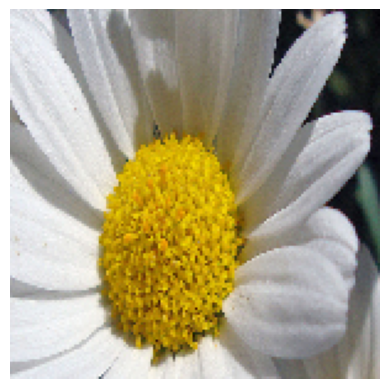

Imagen mostrada: train\daisy\10140303196_b88d3d6cec.jpg


In [4]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Ruta del directorio train
train_dir = 'train'

# Detectar automáticamente la primera clase
first_class = os.listdir(train_dir)[0]

# Obtener la primera imagen de esa clase
img_name = os.listdir(os.path.join(train_dir, first_class))[0]

# Crear la ruta completa de la imagen
img_path = os.path.join(train_dir, first_class, img_name)

# Cargar la imagen
img = image.load_img(img_path, target_size=(150, 150))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')
plt.show()

print("Imagen mostrada:", img_path)


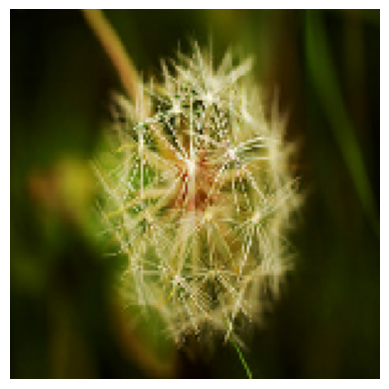

Imagen cargada desde: train/dandelion/10043234166_e6dd915111_n.jpg


In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Ruta correcta en Google Colab
img_path = 'train/dandelion/10043234166_e6dd915111_n.jpg'

# Cargar la imagen
img = image.load_img(img_path, target_size=(150, 150))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')
plt.show()

print("Imagen cargada desde:", img_path)

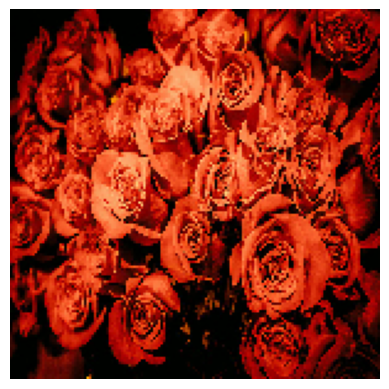

In [6]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

train_dir = 'train'
class_name = 'rose'

img_name = os.listdir(os.path.join(train_dir, class_name))[0]
img_path = os.path.join(train_dir, class_name, img_name)

img = image.load_img(img_path, target_size=(150, 150))

plt.imshow(img)
plt.axis('off')
plt.show()



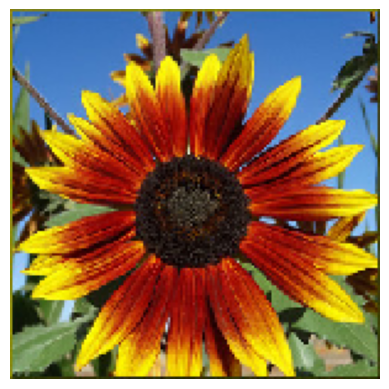

Imagen cargada desde: train\sunflower\10386503264_e05387e1f7_m.jpg


In [7]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

train_dir = 'train'
class_name = 'sunflower'

img_name = os.listdir(os.path.join(train_dir, class_name))[0]
img_path = os.path.join(train_dir, class_name, img_name)

img = image.load_img(img_path, target_size=(150, 150))

plt.imshow(img)
plt.axis('off')
plt.show()

print("Imagen cargada desde:", img_path)


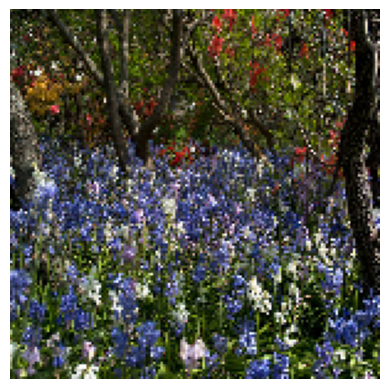

Imagen cargada desde: train/tulip/10094729603_eeca3f2cb6.jpg


In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Ruta correcta en Google Colab
img_path = 'train/tulip/10094729603_eeca3f2cb6.jpg'

# Cargar la imagen
img = image.load_img(img_path, target_size=(150, 150))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')
plt.show()

print("Imagen cargada desde:", img_path)


## Construcción del Modelo

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_clases = trenogen.num_classes

modelo_cnn = Sequential([ # Primera capa convolucional con 32 filtros
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2), #reduce la imagen a la mitad, mantiene lo esencial

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),#conversion de las características extraídas en un vector 1D para clasificar

    Dense(128, activation='relu'),# Capa completamente conectada que combian caracteristicas para decidir la clase
    Dropout(0.5),

    Dense(num_clases, activation='softmax')#salida: num de clases detectadas, softmax las salidas en probabilidades
])                                         #Capa que decide a que categoria pertenece cada imagen

#Compilación del modelo
modelo_cnn.compile(
    optimizer='adam',#ajusta los pesos
    loss='categorical_crossentropy',#Función de perdida para clasificación multiclase
    metrics=['accuracy']#pocentaje de imagenes que clasifica correctamente
)

modelo_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,997 (18.42 MB)

 Trainable params: 4,828,997 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del Modelo

In [ ]:
historia = modelo_cnn.fit(
    trenogen,#conjunto de entrenamiento
    epochs=20, #Se revisa el dataset 20 veces
    validation_data=validaciongen #evalua el rendimiento en datos nunca vistos
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.3256 - loss: 1.5891 - val_accuracy: 0.4972 - val_loss: 1.2126
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5316 - loss: 1.1543 - val_accuracy: 0.5642 - val_loss: 1.1740
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.5511 - loss: 1.1420 - val_accuracy: 0.5587 - val_loss: 1.0725
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6175 - loss: 0.9969 - val_accuracy: 0.5959 - val_loss: 1.0031
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6415 - loss: 0.9330 - val_accuracy: 0.5717 - val_loss: 1.1070
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6401 - loss: 0.9263 - val_accuracy: 0.6201 - val_loss: 0.9362
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6807 - loss: 0.8669 - val_accuracy: 0.6387 - val_loss: 0.8884
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.7113 - loss: 0.7835 - val_accuracy: 0.6797 - v

Curvas de Aprendizaje (Accuracy/Loss)

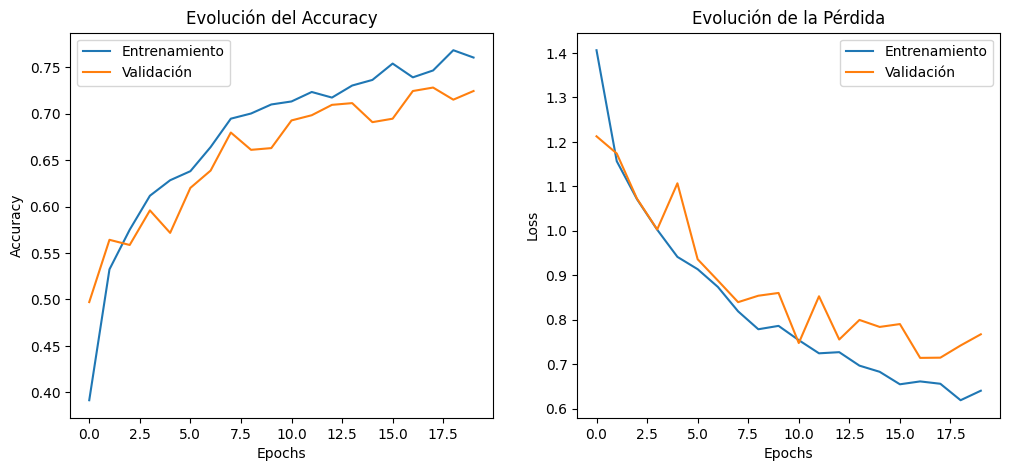

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(historia.history['accuracy'], label='Entrenamiento')
plt.plot(historia.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Evaluación del Modelo

In [ ]:
loss, acc = modelo_cnn.evaluate(validaciongen)

print(f"Precisión en validación: {acc:.4f}")
print(f"Pérdida en validación: {loss:.4f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 513ms/step - accuracy: 0.7668 - loss: 0.6722
Precisión en validación: 0.7244
Pérdida en validación: 0.7675


El modelo alcanzó una precisión del 72.44% y una pérdida de 0.7675 en el conjunto de validación, lo cual indica un desempeño moderado en la clasificación de las imágenes. Estos valores muestran que la CNN logra reconocer patrones relevantes, aunque aún mantiene un margen de error considerable. Los resultados son consistentes con modelos básicos construidos desde cero y pueden ser mejorados mediante técnicas de optimización y regularización.

Matriz de Confusión

17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 412ms/step


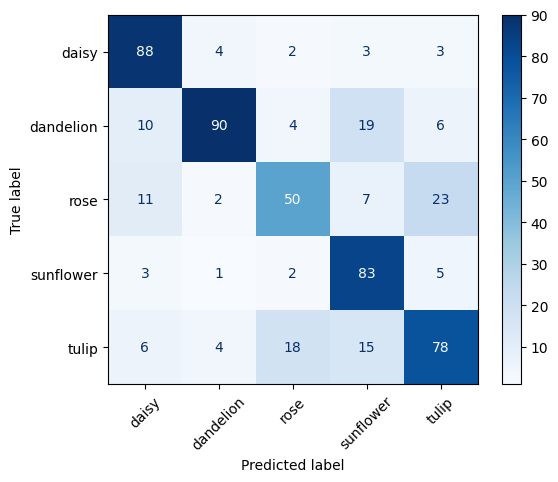

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Obtener predicciones
y_pred = modelo_cnn.predict(validaciongen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Etiquetas reales
y_true = validaciongen.classes

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
labels = list(validaciongen.class_indices.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.show()


La matriz de confusión evidencia que el modelo logra identificar correctamente la mayoría de imágenes de flores, con especial precisión en dandelion, sunflower y daisy. Las principales dificultades se encuentran en la clasificación de la clase rose, que presenta confusiones con tulip y daisy debido a similitudes visuales. Estos resultados son consistentes con el nivel de precisión global alcanzado (≈72%), mostrando que el modelo tiene un desempeño satisfactorio para una CNN básica.

In [10]:
import itertools
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
num_clases = trenogen.num_classes  # Asegúrate de definirlo


def random_tuning(trenogen, validaciongen, num_clases, n_trials = 10, epochs = 5, seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    dropouts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
    learning_rates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
    batch_sizes = [16, 32, 64]
    results = []
    best_acc = 0
    best_model = None
    best_params = None
    combinaciones = [(i,j,k) for i in dropouts for j in learning_rates for k in batch_sizes]
    combinaciones = random.sample(combinaciones, n_trials)
    for i in range(n_trials):
        dr = combinaciones[i][0]
        lr = combinaciones[i][1]
        batch = combinaciones[i][2]
        mod = Sequential([
            Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
            MaxPooling2D(2,2),
            Conv2D(64,(3,3),activation='relu'),
            MaxPooling2D(2,2),
            Conv2D(128,(3,3),activation='relu'),
            MaxPooling2D(2,2),
            Flatten(),
            Dense(128,activation='relu'),
            Dropout(dr),
            Dense(num_clases,activation='softmax')
        ])
        
        mod.compile(
            optimizer=Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        print(f"Modelo{i} => dropout: {dr}, learning_ratt:{lr}, batch_size: {batch}")
        mod.fit(trenogen, validation_data = validaciongen, epochs=epochs, batch_size=batch, verbose=0)
        loss, acc = mod.evaluate(validaciongen, verbose=0)
        results.append({'dropout': dr, 'lr': lr, 'batch': batch, 'val_acc': acc})
        print(f"Trial {i+1}: Dropout={dr}, LR={lr}, Batch={batch}, Val Acc={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_model = mod
            best_params = {'dropout': dr, 'lr': lr, 'batch': batch}
        
    print(f"\nMejor combinación: {best_params}, Val Acc: {best_acc:.4f}")
    return best_model, best_params, results



best_model, best_params, results = random_tuning(
    trenogen,
    validaciongen,
    num_clases=num_clases,
    n_trials=10,
    epochs=10
)

Modelo0 => dropout: 0.4, learning_ratt:0.01, batch_size: 16
Trial 1: Dropout=0.4, LR=0.01, Batch=16, Val Acc=0.2402
Modelo1 => dropout: 0.1, learning_ratt:0.001, batch_size: 64
Trial 2: Dropout=0.1, LR=0.001, Batch=64, Val Acc=0.6704
Modelo2 => dropout: 0.1, learning_ratt:5e-05, batch_size: 16
Trial 3: Dropout=0.1, LR=5e-05, Batch=16, Val Acc=0.5996
Modelo3 => dropout: 0.5, learning_ratt:0.0005, batch_size: 32
Trial 4: Dropout=0.5, LR=0.0005, Batch=32, Val Acc=0.6071
Modelo4 => dropout: 0.2, learning_ratt:0.001, batch_size: 64
Trial 5: Dropout=0.2, LR=0.001, Batch=64, Val Acc=0.7076
Modelo5 => dropout: 0.2, learning_ratt:0.0005, batch_size: 32
Trial 6: Dropout=0.2, LR=0.0005, Batch=32, Val Acc=0.6648
Modelo6 => dropout: 0.2, learning_ratt:0.0001, batch_size: 32
Trial 7: Dropout=0.2, LR=0.0001, Batch=32, Val Acc=0.6425
Modelo7 => dropout: 0.1, learning_ratt:0.005, batch_size: 64
Trial 8: Dropout=0.1, LR=0.005, Batch=64, Val Acc=0.5940
Modelo8 => dropout: 0.1, learning_ratt:0.001, batch_

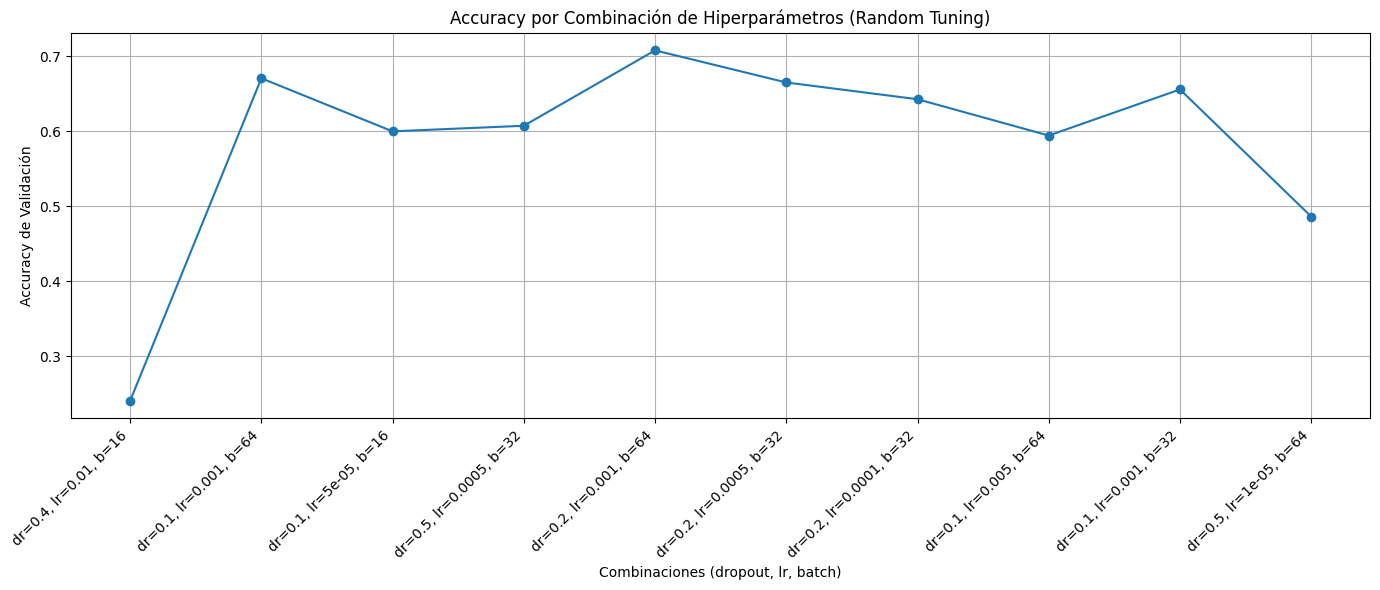

In [ ]:
import matplotlib.pyplot as plt
labels = [
    f"dr={r['dropout']}, lr={r['lr']}, b={r['batch']}"
    for r in results
]
accuracies = [r['val_acc'] for r in results]

plt.figure(figsize=(14, 6))
plt.plot(range(len(results)), accuracies, marker='o')

plt.xticks(range(len(results)), labels, rotation=45, ha='right')
plt.xlabel("Combinaciones (dropout, lr, batch)")
plt.ylabel("Accuracy")
plt.title("Diferentes combinaciones de hiperparametros")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
###Guardando mejor modelo de tuning
best_model.save("best_tuned_model.h5")